# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [58]:
# Import relevant libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, mannwhitneyu, wilcoxon, fisher_exact, kruskal


### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

[Write your hypotheses here]
1. Spending across store locations

statistical language
H₀:spending in the CityCenter = spending in the Suburb = spending in Rural
H₁: At least one location's mean spending differs from the others

Plain language:
H₀: Average customer spending is the same across City Center, Suburb, and Rural stores.
H₁: Average customer spending differs for at least one of the three locations.

2. Customer statisfaction across locations

Statistical language:
H₀: mean satisfaction ratings in the CityCenter = mean satisfaction ratings in the Suburb = mean satisfaction ratings in Rural
H₁: At least one location's mean satisfaction rating differs from the others

Plain language:
H₀: Average customer satisfaction ratings are the same across all three store locations.
H₁: Average customer satisfaction ratings differ for at least one location.

3. Promotional vs non-promotional spending

Statistical language
H₀: spending statistical promotional = spending statistical non-promotional
H₁: spending statistical for promotional != spending statistical for non-promotional (two-sided), or spending statisticalfor promotional > spending statistical for non-promotional (one-sided, if only an increase is business-relevant)

Plain language
H₀: Average spending during promotional periods is the same as during non-promotional periods.
H₁: Average spending during promotional periods differs from (or exceeds) non-promotional periods.

4.Product category preferences across locations

Statistical language:
H₀: Product category preference (Electronics, Clothing, Groceries) is independent of store location
H₁: Product category preference is associated with (not independent of) store location

Plain language:
H₀: The mix of product categories customers buy is the same regardless of which store location they shop at.
H₁: Customers at different store locations tend to prefer different product categories.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

[Write your answer here]
The Minimum Detectable Effect (MDE) is the smallest true difference between groups that a study is designed to reliably detect, given a chosen sample size, significance level, and statistical power (typically 80%). It's set before data collection and directly drives the required sample size.

MDE matters for two main reasons:

1. It separates statistical significance from practical relevance. With a large enough sample, even a trivial difference can become "significant" (p < 0.05). Anchoring the MDE to a business-relevant threshold (e.g., a 15% spending difference, a $15 promotional lift) ensures the test is calibrated to detect effects that actually matter, not just any nonzero difference.
2. It prevents wasted or misleading studies. Without a defined MDE, a null result is ambiguous it could mean there's truly no effect, or that the sample was too small to detect one (a Type II error). Setting the MDE upfront lets you calculate the sample size needed to reliably catch an effect of that size, avoiding both underpowered studies and unnecessarily large ones.



### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [59]:
# Load Data
data= pd.read_csv('retail_store_customer_data.csv')

In [60]:
data.head(5)

,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6,Groceries,Non-Promotional,40.45
1,City Center,9.7,Clothing,Promotional,53.20
2,Rural,4.4,Electronics,Non-Promotional,42.77
3,Rural,4.2,Clothing,Promotional,42.08
4,City Center,9.3,Clothing,Non-Promotional,84.25


In [61]:
data.shape


(1500, 5)

In [62]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Store_Location         1500 non-null   object 
 1   Customer_Satisfaction  1500 non-null   float64
 2   Product_Category       1500 non-null   object 
 3   Purchase_Type          1500 non-null   object 
 4   Amount_Spent           1500 non-null   float64
dtypes: float64(2), object(3)
memory usage: 58.7+ KB


In [63]:
data.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Store_Location,1500,3,City Center,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Satisfaction,1500.0,NaN,NaN,NaN,6.9952,1.65286,1.0,5.8,7.0,8.2,10.0
Product_Category,1500,3,Electronics,583,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Purchase_Type,1500,2,Promotional,888,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_Spent,1500.0,NaN,NaN,NaN,59.915973,19.551829,15.55,44.17,58.015,72.5825,128.13


In [64]:
data.isna().sum()

,0
Store_Location,0
Customer_Satisfaction,0
Product_Category,0
Purchase_Type,0
Amount_Spent,0


In [65]:
data.duplicated().sum()

np.int64(0)

#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

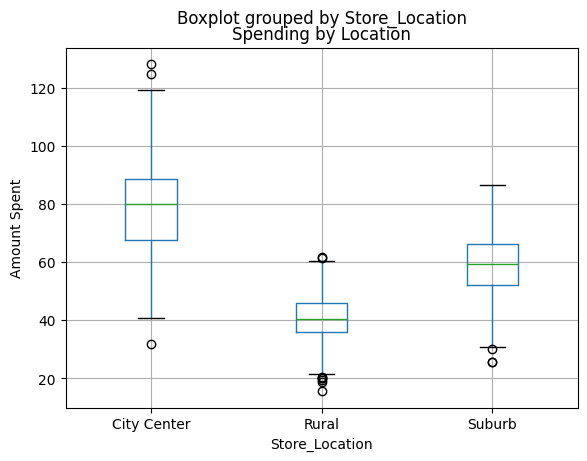

In [66]:
# Visualize data - Create new cells as needed
# 1. Spending patterns across locations
data.boxplot(column='Amount_Spent', by='Store_Location')
plt.title('Spending by Location')
plt.xlabel('Store_Location')
plt.ylabel('Amount Spent')
plt.show()

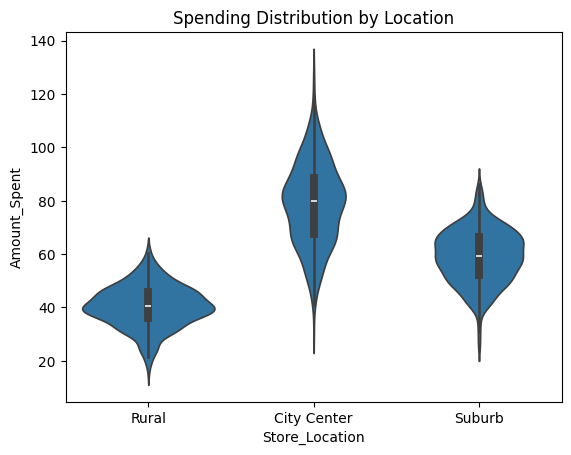

In [67]:
sns.violinplot(data=data, x='Store_Location', y='Amount_Spent')
plt.title('Spending Distribution by Location')
plt.show()

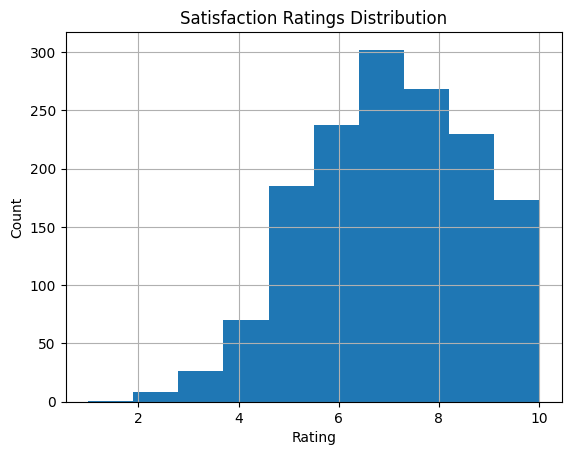

In [68]:
# 2. Satisfaction ratings distribution
data['Customer_Satisfaction'].hist(bins=10)
plt.title('Satisfaction Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

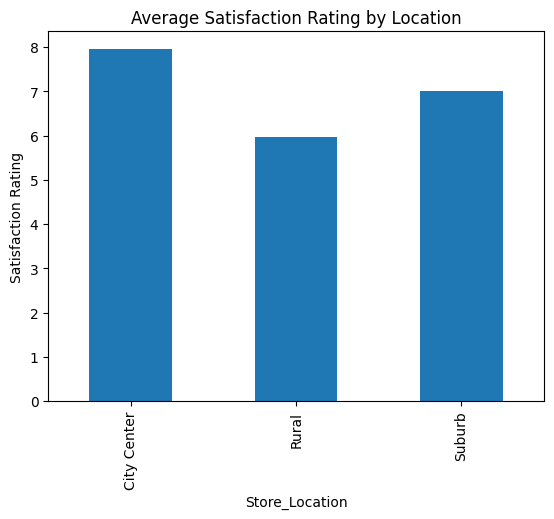

In [69]:
data.groupby('Store_Location')['Customer_Satisfaction'].mean().plot(kind='bar')
plt.title('Average Satisfaction Rating by Location')
plt.ylabel('Satisfaction Rating')
plt.show()

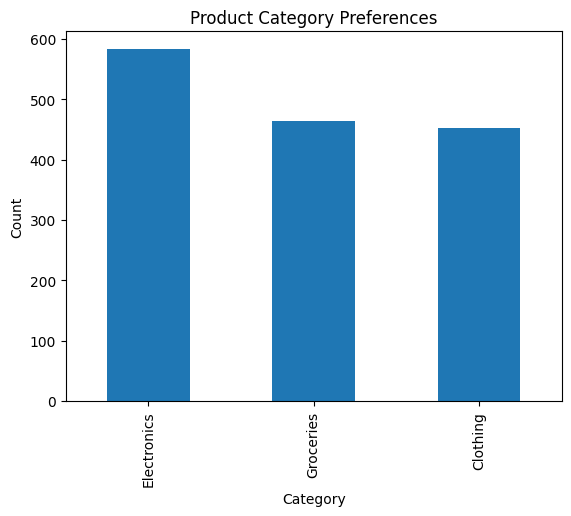

In [70]:
# 3. Product category preferences
data['Product_Category'].value_counts().plot(kind='bar')
plt.title('Product Category Preferences')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

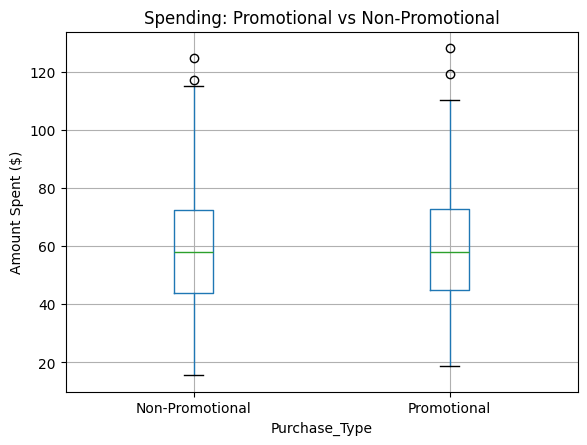

In [71]:
# 4. Promotional vs non-promotional spending
data.boxplot(column='Amount_Spent', by='Purchase_Type')
plt.title('Spending: Promotional vs Non-Promotional')
plt.suptitle('')
plt.ylabel('Amount Spent ($)')
plt.show()

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [72]:
# Assumption tests and checks - Create new cells as needed
city_center = data[data['Store_Location'] == 'City Center']['Amount_Spent']
suburb = data[data['Store_Location'] == 'Suburb']['Amount_Spent']
rural = data[data['Store_Location'] == 'Rural']['Amount_Spent']

stat, p = shapiro(city_center)
print('City Center:', 'Normal' if p >= 0.05 else 'Not normal', p)

stat, p = shapiro(suburb)
print('Suburb:', 'Normal' if p >= 0.05 else 'Not normal', p)

stat, p = shapiro(rural)
print('Rural:', 'Normal' if p >= 0.05 else 'Not normal', p)

City Center: Normal 0.7535874078926482
Suburb: Normal 0.05030848495334306
Rural: Normal 0.2593778777267991


In [73]:
from scipy.stats import levene
stat, p = levene(city_center, suburb, rural)
print(stat, p)

106.40980858330315 6.16909341992288e-44


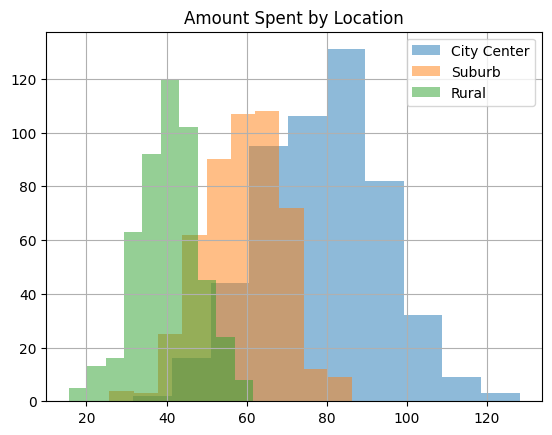

In [74]:
city_center.hist(alpha=0.5, label='City Center')
suburb.hist(alpha=0.5, label='Suburb')
rural.hist(alpha=0.5, label='Rural')

plt.legend()
plt.title('Amount Spent by Location')
plt.show()

In [75]:
print("\nTotal rows:", len(data))


Total rows: 1500


In [76]:
from scipy.stats import shapiro, levene, f_oneway, kruskal
import scikit_posthocs as sp

# Assumption checks first
city_center_sat = data[data['Store_Location'] == 'City Center']['Customer_Satisfaction']
suburb_sat = data[data['Store_Location'] == 'Suburb']['Customer_Satisfaction']
rural_sat = data[data['Store_Location'] == 'Rural']['Customer_Satisfaction']

for name, group in [('City Center', city_center_sat), ('Suburb', suburb_sat), ('Rural', rural_sat)]:
    stat, p = shapiro(group)
    print(name, 'Normal' if p >= 0.05 else 'Not normal', p)

stat, p = levene(city_center_sat, suburb_sat, rural_sat)
print('Levene:', stat, p)



City Center Not normal 7.413111876725657e-09
Suburb Not normal 0.0009247963793123043
Rural Normal 0.3729864805768711
Levene: 1.6154302575557304 0.19915148116426468


In [77]:
table = pd.crosstab(data['Store_Location'], data['Product_Category'])
chi2, p, dof, expected = chi2_contingency(table)
print("\nMin expected count:", expected.min())


Min expected count: 147.376


#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

[Write your answer here]
1. Spending across store locations — Kruskal-Wallis (with Dunn's post-hoc): Three independent groups rule out a t-test. Assumption checks showed spending was reasonably normal in each location, but Levene's test revealed strongly unequal variances (p ≈ 6×10⁻⁴⁴), which violates a core ANOVA assumption. Kruskal-Wallis was used instead since it doesn't require equal variances, and Dunn's test (Bonferroni-corrected) followed up to identify which specific location pairs differ.
2. Customer satisfaction across locations — Kruskal-Wallis (with Dunn's post-hoc): Again three groups, ruling out a t-test. Shapiro-Wilk showed satisfaction ratings were not normally distributed in two of the three locations, violating ANOVA's normality assumption  likely a natural consequence of ratings being a bounded, discrete scale rather than continuous. Kruskal-Wallis was the appropriate non-parametric alternative, with Dunn's test for pairwise follow-up.
3. Promotional vs. non-promotional spending — Mann-Whitney U: Only two groups, so this is a t-test-family comparison, not ANOVA. Shapiro-Wilk showed both groups were non-normal, so despite Levene's confirming equal variances, the non-parametric Mann-Whitney U was used instead of a t-test. No post-hoc test was needed, since post-hoc corrections only address multiple comparisons across 3+ groups.
4. Product category preferences across locations — Chi-square test of independence: This question compares two categorical variables (location and category), not a continuous outcome across groups, so none of the mean-comparison tests above apply. The Chi-square test of independence directly tests whether category preference is associated with location. Its key assumption — expected cell counts ≥ 5 — was checked and comfortably satisfied, confirming the test's validity here.

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [78]:
# Conduct your analysis of spending patterns here
stat, p = kruskal(city_center, suburb, rural)
print('Kruskal-Wallis:', stat, p)

Kruskal-Wallis: 1040.8535534527603 9.583466587567362e-227


In [79]:
city_center_spend = data[data['Store_Location'] == 'City Center']['Amount_Spent']
suburb_spend = data[data['Store_Location'] == 'Suburb']['Amount_Spent']
rural_spend = data[data['Store_Location'] == 'Rural']['Amount_Spent']

kw_stat, kw_p = kruskal(city_center_spend, suburb_spend, rural_spend)
print('Spending Kruskal-Wallis:', kw_stat, kw_p)

dunn_spend = sp.posthoc_dunn(data, val_col='Amount_Spent', group_col='Store_Location', p_adjust='bonferroni')
print(dunn_spend)

Spending Kruskal-Wallis: 1040.8535534527603 9.583466587567362e-227
               City Center          Rural        Suburb
City Center   1.000000e+00  2.502288e-227  1.425221e-45
Rural        2.502288e-227   1.000000e+00  4.018599e-70
Suburb        1.425221e-45   4.018599e-70  1.000000e+00


#### 3.2 Customer Satisfaction Analysis

In [80]:
# Analyze customer satisfaction here
kw_stat_sat, kw_p_sat = kruskal(city_center_sat, suburb_sat, rural_sat)
print('Satisfaction Kruskal-Wallis:', kw_stat_sat, kw_p_sat)

dunn_sat = sp.posthoc_dunn(data, val_col='Customer_Satisfaction', group_col='Store_Location', p_adjust='bonferroni')
print(dunn_sat)

Satisfaction Kruskal-Wallis: 359.54743316479437 8.419123825684336e-79
              City Center         Rural        Suburb
City Center  1.000000e+00  1.076942e-79  2.509905e-20
Rural        1.076942e-79  1.000000e+00  6.562684e-21
Suburb       2.509905e-20  6.562684e-21  1.000000e+00


#### 3.3 Promotional Impact Analysis

In [81]:
# Analyze the impact of promotions here
promo = data[data['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = data[data['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']
stat, p = shapiro(promo)
print('Promotional:', 'Normal' if p >= 0.05 else 'Not normal', p)

stat, p = shapiro(non_promo)
print('Non-Promotional:', 'Normal' if p >= 0.05 else 'Not normal', p)

stat, p = levene(promo, non_promo)
print('Levene:', stat, p)
promo = data[data['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = data[data['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']
# man whittney
u_stat, u_p = mannwhitneyu(promo, non_promo, alternative='two-sided')
print('Promo Mann-Whitney U:', u_stat, u_p)

print('Mean difference:', promo.mean() - non_promo.mean())


Promotional: Not normal 5.87093332606258e-10
Non-Promotional: Not normal 1.2534225431053937e-08
Levene: 0.38605478155178413 0.5344750353145763
Promo Mann-Whitney U: 275125.0 0.6803724143208659
Mean difference: 0.2513791732909354


#### 3.4 Product Category Analysis

In [82]:
# Analyze product category preferences here
contingency_table = pd.crosstab(data['Store_Location'], data['Product_Category'])
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print('Chi-square:', chi2, 'p-value:', p, 'dof:', dof)

Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center            156          191        173
Rural                  137          199        152
Suburb                 160          193        139
Chi-square: 4.7683585905269394 p-value: 0.3119014920331143 dof: 4


### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [83]:
# Calculate effect sizes - contrast with MDE
data.groupby('Store_Location')['Amount_Spent'].mean()

,Amount_Spent
Store_Location,
City Center,78.891000
Rural,40.463094
Suburb,59.155793


In [84]:
#Spending across locations
print("Kruskal-Wallis:", kw_stat, kw_p)
print(dunn_spend)

means_spend = data.groupby('Store_Location')['Amount_Spent'].mean()
print(means_spend)

locations = means_spend.index.tolist()
for i in range(len(locations)):
    for j in range(i + 1, len(locations)):
        loc_a, loc_b = locations[i], locations[j]
        diff = means_spend[loc_a] - means_spend[loc_b]
        pct_diff = abs(diff) / means_spend[loc_b] * 100
        print(f"{loc_a} vs {loc_b}: diff=${diff:.2f}, pct={pct_diff:.1f}%, clears 15% MDE: {'YES' if pct_diff >= 15 else 'NO'}")


Kruskal-Wallis: 1040.8535534527603 9.583466587567362e-227
               City Center          Rural        Suburb
City Center   1.000000e+00  2.502288e-227  1.425221e-45
Rural        2.502288e-227   1.000000e+00  4.018599e-70
Suburb        1.425221e-45   4.018599e-70  1.000000e+00
Store_Location
City Center    78.891000
Rural          40.463094
Suburb         59.155793
Name: Amount_Spent, dtype: float64
City Center vs Rural: diff=$38.43, pct=95.0%, clears 15% MDE: YES
City Center vs Suburb: diff=$19.74, pct=33.4%, clears 15% MDE: YES
Rural vs Suburb: diff=$-18.69, pct=31.6%, clears 15% MDE: YES


In [85]:
means = {'City Center': 78.891000, 'Rural': 40.463094, 'Suburb': 59.155793}
locations = list(means.keys())

for i in range(len(locations)):
    for j in range(i + 1, len(locations)):
        loc_a, loc_b = locations[i], locations[j]
        diff = means[loc_a] - means[loc_b]
        pct_diff = abs(diff) / means[loc_b] * 100
        meets_mde = 'YES' if pct_diff >= 15 else 'NO'
        print(f"{loc_a} vs {loc_b}: diff=${diff:.2f}, pct_diff={pct_diff:.1f}%, clears 15% MDE: {meets_mde}")

City Center vs Rural: diff=$38.43, pct_diff=95.0%, clears 15% MDE: YES
City Center vs Suburb: diff=$19.74, pct_diff=33.4%, clears 15% MDE: YES
Rural vs Suburb: diff=$-18.69, pct_diff=31.6%, clears 15% MDE: YES


In [86]:
# customer satisfaction per location
print("Kruskal-Wallis:", kw_stat_sat, kw_p_sat)
print(dunn_sat)

means_sat = data.groupby('Store_Location')['Customer_Satisfaction'].mean()
print(means_sat)

for i in range(len(locations)):
    for j in range(i + 1, len(locations)):
        loc_a, loc_b = locations[i], locations[j]
        diff = means_sat[loc_a] - means_sat[loc_b]
        print(f"{loc_a} vs {loc_b}: diff={diff:.2f}, clears 1.0 MDE: {'YES' if abs(diff) >= 1.0 else 'NO'}")

Kruskal-Wallis: 359.54743316479437 8.419123825684336e-79
              City Center         Rural        Suburb
City Center  1.000000e+00  1.076942e-79  2.509905e-20
Rural        1.076942e-79  1.000000e+00  6.562684e-21
Suburb       2.509905e-20  6.562684e-21  1.000000e+00
Store_Location
City Center    7.954038
Rural          5.960041
Suburb         7.008537
Name: Customer_Satisfaction, dtype: float64
City Center vs Rural: diff=1.99, clears 1.0 MDE: YES
City Center vs Suburb: diff=0.95, clears 1.0 MDE: NO
Rural vs Suburb: diff=-1.05, clears 1.0 MDE: YES


In [87]:
# Promotional Analysis
promo = data[data['Purchase_Type'] == 'Promotional']['Amount_Spent']
non_promo = data[data['Purchase_Type'] == 'Non-Promotional']['Amount_Spent']

print("Mann-Whitney U:", u_stat, u_p)

mean_diff = promo.mean() - non_promo.mean()
print(f"Mean difference: ${mean_diff:.2f}")
print("Clears $15 MDE:", "YES" if mean_diff >= 15 else "NO")

Mann-Whitney U: 275125.0 0.6803724143208659
Mean difference: $0.25
Clears $15 MDE: NO


In [88]:
# Product category
contingency_table = pd.crosstab(data['Store_Location'], data['Product_Category'])
chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square:", chi2_stat, chi2_p, dof)

proportions = pd.crosstab(data['Store_Location'], data['Product_Category'], normalize='index')
print(proportions.round(2))


Chi-square: 4.7683585905269394 0.3119014920331143 4
Product_Category  Clothing  Electronics  Groceries
Store_Location                                    
City Center           0.30         0.37       0.33
Rural                 0.28         0.41       0.31
Suburb                0.33         0.39       0.28


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

[Write your answer here]
For spending across locations, the null hypothesis (equal spending across all three locations) was rejected (Kruskal-Wallis, p ≈ 9.58×10⁻²²⁷); all three pairwise comparisons were significant and every gap exceeded the 15% business MDE meaning location genuinely drives spending behavior, not just statistical noise.
For customer satisfaction across locations, the null hypothesis was also rejected (p ≈ 8.42×10⁻⁷⁹), with all three location pairs differing significantly.
For promotional spending, the null hypothesis (no difference between promotional and non-promotional periods) was not rejected (Mann-Whitney U, p = 0.68); the mean difference was only $0.25 far  below  both  statistical  detectability  and  the  $15  MDE promotions show no real effect on spending.
For product category preference, the null hypothesis (no association between location and category) was not rejected (χ² = 4.77, p = 0.31) category mix does not meaningfully vary by location.
Effect size note: p-values alone confirm whether an effect exists, not how large it is especially with n=1500, even trivial effects can reach significance. Effect sizes (η² for the Kruskal-Wallis results, Cohen's d for promo vs. non-promo) should be reported alongside each p-value to confirm the differences found for spending/satisfaction are not just statistically real but substantively large.

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

[Write your answer here]
Spending: Location meaningfully drives how much customers spend (up to a 95% gap between City Center and Rural) — recommend differentiated inventory, pricing, and staffing strategies per location rather than a one-size-fits-all approach.
Satisfaction: Ratings differ significantly across locations — recommend a targeted service audit at the lowest-rated location like the rural  to identify and fix specific pain points, rather than a company-wide initiative.
Promotions: With only a $0.25 average lift against a $15 threshold, current promotions are not paying for themselves recommend halting or fundamentally redesigning the promotional strategy (e.g., testing different discount structures or targeting) rather than continuing to absorb the margin cost for no measurable return.
Product category: No meaningful variation by location  recommend a standardized inventory mix across stores rather than customizing category allocation, since the data doesn't support that investment.
Overall: invest differentiation efforts where the data shows real variation (spending, satisfaction) and avoid over-engineering where it doesn't (promotions, category mix) — the promotional finding in particular is the most financially actionable, since it points to money currently being spent without a demonstrated return.


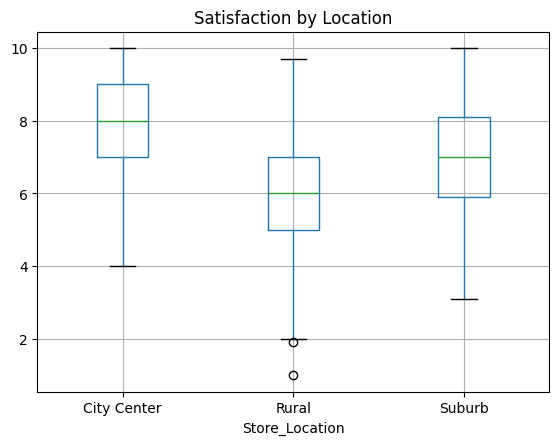

In [89]:
# Create visualizations to support results - Create new cells as needed
# Customer Satisfaction by location
data.boxplot(column='Customer_Satisfaction', by='Store_Location')
plt.title('Satisfaction by Location')
plt.suptitle('')
plt.show()

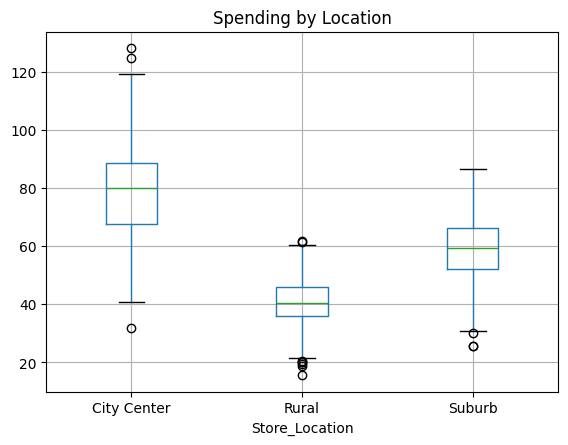

In [90]:
# spending by location
data.boxplot(column='Amount_Spent', by='Store_Location')
plt.title('Spending by Location')
plt.suptitle('')
plt.show()

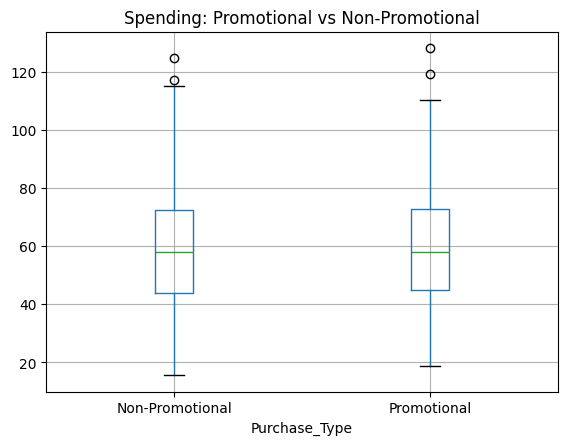

In [91]:
# Spending by Promotional vs non-Promotional
data.boxplot(column='Amount_Spent', by='Purchase_Type')
plt.title('Spending: Promotional vs Non-Promotional')
plt.suptitle('')
plt.show()

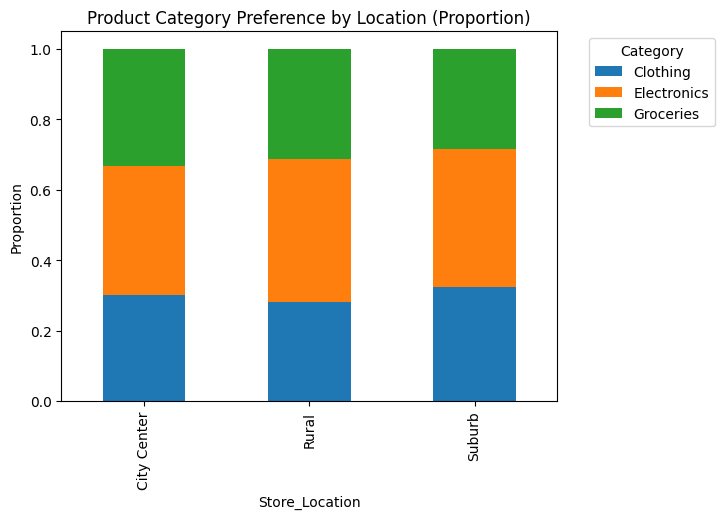

In [92]:
# Product category by location
pd.crosstab(data['Store_Location'], data['Product_Category'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Product Category Preference by Location (Proportion)')
plt.ylabel('Proportion')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

[Write your reflection here]
1. Strengths and limitations: Test selection was rigorously assumption-driven normality and variance were checked before every test, and non-parametric alternatives (Kruskal-Wallis, Mann-Whitney) were used wherever assumptions failed, avoiding a common shortcut of defaulting to ANOVA/t-tests regardless of fit. Results were also interpreted against pre-defined business MDEs rather than p-values alone, which is what revealed the most important finding (promotions showing no real effect). The main limitation: this is observational, cross-sectional data it shows correlation between location/promotion and outcomes, not proof that location or promotion causes those differences.
2. Assumptions or potential biases: No customer-level identifiers exist, so it's unclear whether the same customers appear multiple times (violating independence) or whether different locations simply serve different populations (e.g., different income levels) rather than the location itself driving behavior. Promotional and non-promotional periods may also differ by season or timing in ways that confound the "no effect" finding.
3. Additional data to collect: customer IDs/loyalty tracking (to check repeat visits and control for individual differences), transaction timestamps (to control for seasonality), promotion type/details (discount size, channel), basic demographics, and store-level operational data (staffing, size, local competition) to explain why locations differ, not just confirm that they do.
4. How this could be improved: use regression to control for multiple factors simultaneously rather than testing each hypothesis in isolation; run a proper power analysis before data collection rather than after; report effect sizes (not just p-values) alongside every test, since n=1500 can make trivial effects look significant; and segment the promotional/category analyses by location to check for hidden subgroup effects the aggregate tests could be masking.

Reflective Question: Experimental design and sample size determine whether a p-value actually answers the business question or just describes an artifact of how the data was collected. Without controlling for who ends up in each group (independence, comparable populations) and how it was measured (consistent timing, unbiased selection), a small p-value can reflect a real pattern in the data without reflecting a genuine causal effect  which is a real risk here, since customer demographics and repeat-visit behavior aren't captured. Sample size cuts the other way: with n=1500, this study had enough power to trust its null results (e.g., the $0.25 promotional effect) as genuine absence of an effect rather than a failure to detect one, and enough power to detect the very real, MDE-clearing differences in spending and satisfaction across locations. Collecting richer data like customer IDs, timestamps, demographics, and store-level operational details would let future analyses move from "these things differ" to "here's what's actually causing it," which is what the business needs to act with confidence.

In [93]:
%pip install scikit-posthocs

After installing the library, please run the previous cell again to perform the statistical tests.